<a href="https://colab.research.google.com/github/nihedzaoui/flyrank-ml-internship/blob/main/w07_action_playbook.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# ML-10 — Content Action Playbook

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/nihedzaoui/flyrank-ml-internship/blob/main/work/notebooks/w07_action_playbook.ipynb?flush_cache=true)

This skeleton is yours to fill. Work the sections **in order** — each one has a one-line hint. Simple words, honest numbers.

> Working with an AI assistant? Tell it to read `skills/README.md` first and load the one skill this assignment names on its card.

In [2]:
from pathlib import Path
import pandas as pd
import numpy as np
import os
import shutil

# ============================================================
# ML-10 — Repository and dataset setup
# ============================================================

REPO_ROOT = Path("/content/flyrank-ml-internship")

# Clone repository if it is not already present
if not REPO_ROOT.exists():
    !git clone https://github.com/nihedzaoui/flyrank-ml-internship.git /content/flyrank-ml-internship

DATA_DIR = REPO_ROOT / "data/raw"
DATA_DIR.mkdir(parents=True, exist_ok=True)

DATA_PATH = DATA_DIR / "content_refresh_anonymized.csv"

OUTPUT_DIR = REPO_ROOT / "work/outputs"
FIGURES_DIR = REPO_ROOT / "work/figures"

OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

print("Repository:", REPO_ROOT)
print("Dataset path:", DATA_PATH)
print("Dataset exists:", DATA_PATH.exists())

Repository: /content/flyrank-ml-internship
Dataset path: /content/flyrank-ml-internship/data/raw/content_refresh_anonymized.csv
Dataset exists: False


In [3]:
# ============================================================
# Locate the starter dataset
# ============================================================

possible_paths = [
    DATA_PATH,
    Path("/content/content_refresh_anonymized.csv"),
    Path("/content/drive/MyDrive/content_refresh_anonymized.csv"),
    Path("/content/drive/MyDrive/flyrank-ml-internship/data/raw/content_refresh_anonymized.csv"),
]

found_path = None

for path in possible_paths:
    if path.exists():
        found_path = path
        break

if found_path is None:
    print("Dataset not found in the expected locations.")
    print()
    print("Expected:")
    print(DATA_PATH)
    print()
    print("If the CSV is on your computer, upload it with the next cell.")
else:
    print("Dataset found:")
    print(found_path)

Dataset not found in the expected locations.

Expected:
/content/flyrank-ml-internship/data/raw/content_refresh_anonymized.csv

If the CSV is on your computer, upload it with the next cell.


In [4]:
# ============================================================
# Upload dataset if necessary
# ============================================================

from google.colab import files

if found_path is None:
    uploaded = files.upload()

    uploaded_names = list(uploaded.keys())

    if len(uploaded_names) == 0:
        raise FileNotFoundError(
            "No file was uploaded. Please upload "
            "content_refresh_anonymized.csv."
        )

    # Look specifically for the expected CSV
    csv_candidates = [
        name for name in uploaded_names
        if name.lower().endswith(".csv")
    ]

    if not csv_candidates:
        raise FileNotFoundError(
            "No CSV file was uploaded. Please upload "
            "content_refresh_anonymized.csv."
        )

    uploaded_file = csv_candidates[0]

    if uploaded_file != "content_refresh_anonymized.csv":
        print(
            f"Uploaded file detected: {uploaded_file}"
        )

    shutil.copy(
        Path(uploaded_file),
        DATA_PATH
    )

    found_path = DATA_PATH

    print()
    print("Dataset copied to:")
    print(DATA_PATH)

else:
    print("Upload not required.")

Saving content_refresh_anonymized.csv to content_refresh_anonymized.csv

Dataset copied to:
/content/flyrank-ml-internship/data/raw/content_refresh_anonymized.csv


In [5]:
# ============================================================
# Load starter dataset
# ============================================================

if not DATA_PATH.exists():

    if found_path is not None and Path(found_path).exists():
        DATA_PATH = Path(found_path)

    else:
        raise FileNotFoundError(
            "\nDataset not found.\n\n"
            f"Expected location:\n{DATA_PATH}\n\n"
            "Please upload content_refresh_anonymized.csv "
            "using the previous cell."
        )

df = pd.read_csv(DATA_PATH)

print("Dataset shape:", df.shape)

required_columns = [
    "content_id",
    "client_id",
    "days_since_last_update",
    "impressions_90d",
]

missing_columns = [
    col for col in required_columns
    if col not in df.columns
]

if missing_columns:
    raise ValueError(
        f"Missing required columns: {missing_columns}"
    )

print("\nRequired columns found.")

print("\nMissing values:")
print(df[required_columns].isna().sum())

print("\nDataset preview:")
display(df.head())

assert df.shape[0] == 30000, (
    f"Expected 30,000 rows, found {df.shape[0]}"
)

print("\nDataset check: PASS")

Dataset shape: (30000, 44)

Required columns found.

Missing values:
content_id                0
client_id                 0
days_since_last_update    0
impressions_90d           0
dtype: int64

Dataset preview:


,content_id,client_id,search_volume,competition,competition_level,cpc,content_type,main_intent,word_count,char_count,...,char_count_tier,ctr,avg_position,engagement_rate,scroll_rate,ai_traffic_pct,impression_tier,position_tier,trend_direction,trend_pct
0,content_304f48230142,client_f369cb89fc,10.0,0.67,HIGH,2.05,keyword article,transactional,3221.0,20457.0,...,15000-25000,0.76,10.6,5.88,4.55,0.0,good,striking,down,-41.4
1,content_a1fb4e703a9e,client_4e07408562,90.0,0.01,LOW,0.05,keyword article,informational,2481.0,15562.0,...,15000-25000,0.05,20.3,0.00,10.00,0.0,good,page_3_5,down,-57.7
2,content_9aa793d4d895,client_7f2253d7e2,0.0,0.00,LOW,0.00,keyword article,informational,3515.0,23643.0,...,15000-25000,0.09,36.5,0.00,28.57,0.0,good,page_3_5,down,-60.9
3,content_331d6c4de07b,client_19581e27de,10.0,0.00,LOW,0.00,keyword article,commercial,NaN,NaN,...,NaN,0.49,6.2,1.28,3.45,0.0,good,page_1,stable,-13.8
4,content_d99b7a2d90ca,client_3fdba35f04,0.0,0.00,LOW,0.00,keyword article,informational,2803.0,17469.0,...,15000-25000,0.13,44.0,0.00,24.29,0.0,good,page_3_5,down,-34.7



Dataset check: PASS


## 1. Ranked actions + reason codes

The queue prioritizes content for human review using the validated baseline
from the previous analysis.

An item is prioritized when:

1. it was last updated 91–180 days ago; and
2. it received at least 300 impressions in the last 90 days.

For prioritized items, the score is the observed number of 90-day impressions.
This makes the queue transparent: among items meeting the same staleness
condition, items with more observed search visibility are reviewed first.

### Reason codes

* `stale_visible`: the item is 91–180 days old and has at least 300 recent
  impressions.
* `no_priority_signal`: the item does not meet both baseline conditions.

### Actions

* `review_for_refresh`: send to human review.
* `no_action`: do not prioritize for refresh under this baseline.

The score does not estimate the probability or impact of a successful refresh.
It only determines review order.


In [6]:
# ============================================================
# Build the action playbook
# ============================================================

playbook = df.copy()

# Validated baseline conditions
playbook["target_staleness"] = (
    playbook["days_since_last_update"].between(91, 180)
)

playbook["meaningful_visibility"] = (
    playbook["impressions_90d"] >= 300
)

playbook["priority"] = (
    playbook["target_staleness"]
    & playbook["meaningful_visibility"]
)

# Transparent prioritization score
playbook["score"] = np.where(
    playbook["priority"],
    playbook["impressions_90d"],
    0
)

# Reason codes
playbook["reason_code"] = np.where(
    playbook["priority"],
    "stale_visible",
    "no_priority_signal"
)

# Recommended action
playbook["action"] = np.where(
    playbook["priority"],
    "review_for_refresh",
    "no_action"
)

# Rank highest observed visibility first
playbook = playbook.sort_values(
    ["score", "impressions_90d"],
    ascending=[False, False]
).reset_index(drop=True)

playbook["rank"] = np.arange(1, len(playbook) + 1)

queue_columns = [
    "rank",
    "content_id",
    "client_id",
    "days_since_last_update",
    "impressions_90d",
    "score",
    "reason_code",
    "action",
]

queue = playbook[queue_columns].copy()

print("Total items:", len(queue))
print(
    "Priority candidates:",
    int((queue["score"] > 0).sum())
)

print(
    "Priority rate:",
    f"{(queue['score'] > 0).mean():.2%}"
)

display(queue.head(20))

Total items: 30000
Priority candidates: 7212
Priority rate: 24.04%


,rank,content_id,client_id,days_since_last_update,impressions_90d,score,reason_code,action
0,1,content_5fe46e04994d,client_4e07408562,104,517715,517715,stale_visible,review_for_refresh
1,2,content_2dba2b1f9536,client_6208ef0f77,104,443434,443434,stale_visible,review_for_refresh
2,3,content_2c2606c5d176,client_19581e27de,104,347399,347399,stale_visible,review_for_refresh
3,4,content_cb112fce36be,client_19581e27de,104,309910,309910,stale_visible,review_for_refresh
4,5,content_9532f197bbc8,client_4e07408562,104,309192,309192,stale_visible,review_for_refresh
5,6,content_36ff89c8214e,client_19581e27de,104,295097,295097,stale_visible,review_for_refresh
6,7,content_b28d1efd668f,client_6208ef0f77,104,286608,286608,stale_visible,review_for_refresh
7,8,content_813e88069237,client_6208ef0f77,104,233561,233561,stale_visible,review_for_refresh
8,9,content_c21024970297,client_19581e27de,104,211366,211366,stale_visible,review_for_refresh
9,10,content_c8e9d6ab9013,client_19581e27de,104,208678,208678,stale_visible,review_for_refresh


In [7]:
# ============================================================
# Ranking and reason-code validation
# ============================================================

priority_queue = queue[
    queue["score"] > 0
].copy()

assert priority_queue[
    "days_since_last_update"
].between(91, 180).all()

assert (
    priority_queue["impressions_90d"] >= 300
).all()

assert set(
    queue["reason_code"].unique()
).issubset({
    "stale_visible",
    "no_priority_signal"
})

assert set(
    queue["action"].unique()
).issubset({
    "review_for_refresh",
    "no_action"
})

print("Ranking and reason-code checks: PASS")

Ranking and reason-code checks: PASS


## 2. Intended use and limits

### Intended use

The playbook is intended to help a content team:

* prioritize limited human review time;
* identify older content that still has observable search visibility;
* create a reproducible review queue;
* provide decision-support for possible content refreshes.

### What the score means

A higher score means higher observed impressions in the 90-day window among
items satisfying the 91–180 day staleness condition.

It does not mean:

* higher expected traffic after refresh;
* higher business value;
* higher conversion value;
* higher probability of improvement;
* causal impact from refreshing the content.

### Limits

The baseline uses only:

* days since last update;
* 90-day impressions.

It does not directly evaluate:

* content quality;
* search intent;
* conversion value;
* editorial importance;
* factual accuracy;
* backlink quality;
* business strategy;
* whether an item should actually be changed.

The result is therefore a prioritization queue, not an automated content
decision system.

This notebook is a research and decision-support artifact, not a production
automation system.


In [8]:
# ============================================================
# Section 2 — Intended use and limits
# ============================================================

# Descriptive summary of the signals used by the playbook.
# These statistics describe the current dataset; they are not predictions.

section2_summary = pd.DataFrame({
    "metric": [
        "total_items",
        "median_days_since_last_update",
        "median_impressions_90d",
        "priority_items",
        "priority_rate",
    ],
    "value": [
        len(df),
        df["days_since_last_update"].median(),
        df["impressions_90d"].median(),
        int((queue["score"] > 0).sum()),
        (queue["score"] > 0).mean(),
    ],
})

display(section2_summary)

print("\nInterpretation:")
print(
    "The playbook is a prioritization tool based on observed "
    "staleness and recent visibility."
)
print(
    "It does not predict the effect of refreshing content "
    "or guarantee future performance."
)

,metric,value
0,total_items,30000.0000
1,median_days_since_last_update,20.0000
2,median_impressions_90d,731.0000
3,priority_items,7212.0000
4,priority_rate,0.2404



Interpretation:
The playbook is a prioritization tool based on observed staleness and recent visibility.
It does not predict the effect of refreshing content or guarantee future performance.


## 3. Human review + the no-go list

Every `review_for_refresh` item must be checked by a human before any action is
taken.

### Human review checklist

The reviewer should verify:

1. Is the content still relevant?
2. Is the recorded update date correct?
3. Is the content intentionally stable or evergreen?
4. Are facts, statistics, examples or links outdated?
5. Does the current visibility represent useful user demand?
6. Is there a clear reason to refresh the content?
7. Would a refresh require substantial editorial work?
8. Should the content instead remain unchanged, be merged, redirected, or
   retired?

### Archetype → action mapping

The archetype is assigned during human review. It is not predicted by the
baseline score.

| Archetype              | Review interpretation                          | Suggested action                                |
| ---------------------- | ---------------------------------------------- | ----------------------------------------------- |
| Evergreen / high-value | Still useful but some details may be outdated  | Refresh verified facts, examples and links      |
| Time-sensitive         | Depends on changing information                | Verify all time-sensitive claims before editing |
| Stable / intentional   | Content is intentionally stable                | Usually leave unchanged                         |
| Weak opportunity       | Visibility exists but refresh value is unclear | Review effort versus expected usefulness        |
| Unclear                | Available signals are insufficient             | Manual investigation                            |

### No-go list

The system must never automatically:

* publish edited content;
* rewrite an article;
* delete content;
* redirect content;
* change titles or metadata;
* claim that a refresh will increase traffic;
* claim expected revenue or ROI;
* override editorial review;
* override legal or compliance review;
* treat impressions as business value;
* treat the score as a predicted outcome.

Human reviewers can override any recommendation.

A highly ranked item can be rejected if it is intentionally stable or otherwise
not worth changing. A low-ranked item can still be reviewed when a human has
information that is not represented in this baseline.


In [9]:
# ============================================================
# Section 3 — Human review queue
# ============================================================

review_queue = queue.copy()

# Every prioritized item requires human review.
review_queue["review_required"] = np.where(
    review_queue["action"] == "review_for_refresh",
    True,
    False
)

# Current review status
review_queue["review_status"] = np.where(
    review_queue["review_required"],
    "pending_human_review",
    "not_prioritized"
)

# Explain the reason to the reviewer
review_queue["decision_note"] = np.where(
    review_queue["reason_code"] == "stale_visible",
    "Review freshness, relevance, and usefulness before any change.",
    "No priority signal under the current baseline."
)

print("Human-review queue:")
display(
    review_queue[
        [
            "rank",
            "content_id",
            "days_since_last_update",
            "impressions_90d",
            "score",
            "reason_code",
            "action",
            "review_status",
            "decision_note",
        ]
    ].head(20)
)

Human-review queue:


,rank,content_id,days_since_last_update,impressions_90d,score,reason_code,action,review_status,decision_note
0,1,content_5fe46e04994d,104,517715,517715,stale_visible,review_for_refresh,pending_human_review,"Review freshness, relevance, and usefulness be..."
1,2,content_2dba2b1f9536,104,443434,443434,stale_visible,review_for_refresh,pending_human_review,"Review freshness, relevance, and usefulness be..."
2,3,content_2c2606c5d176,104,347399,347399,stale_visible,review_for_refresh,pending_human_review,"Review freshness, relevance, and usefulness be..."
3,4,content_cb112fce36be,104,309910,309910,stale_visible,review_for_refresh,pending_human_review,"Review freshness, relevance, and usefulness be..."
4,5,content_9532f197bbc8,104,309192,309192,stale_visible,review_for_refresh,pending_human_review,"Review freshness, relevance, and usefulness be..."
5,6,content_36ff89c8214e,104,295097,295097,stale_visible,review_for_refresh,pending_human_review,"Review freshness, relevance, and usefulness be..."
6,7,content_b28d1efd668f,104,286608,286608,stale_visible,review_for_refresh,pending_human_review,"Review freshness, relevance, and usefulness be..."
7,8,content_813e88069237,104,233561,233561,stale_visible,review_for_refresh,pending_human_review,"Review freshness, relevance, and usefulness be..."
8,9,content_c21024970297,104,211366,211366,stale_visible,review_for_refresh,pending_human_review,"Review freshness, relevance, and usefulness be..."
9,10,content_c8e9d6ab9013,104,208678,208678,stale_visible,review_for_refresh,pending_human_review,"Review freshness, relevance, and usefulness be..."


## 4. Monitoring / retrain triggers

The current playbook is a transparent rule-based baseline, not a fitted
predictive model. Therefore, there is no model retraining step in this version.

### Monitoring

The queue should be reviewed periodically for:

* number of prioritized items;
* proportion of items prioritized;
* distribution of days since last update;
* distribution of 90-day impressions;
* changes in the size of the review queue;
* human acceptance and rejection of recommendations;
* outcomes observed after refresh, if those outcomes become available.

### Revisit triggers

The baseline should be reconsidered if:

1. the priority queue becomes unexpectedly large or small;
2. the 91–180 day group no longer represents useful visible content;
3. human reviewers frequently reject recommendations;
4. important content categories are systematically missing;
5. the available data definitions change;
6. additional validated signals become available.

### Retraining trigger

A predictive model should only be introduced if future labeled outcomes become
available and a predictive objective is justified.

Any future predictive model must be evaluated separately. It should not silently
replace this transparent baseline.

No future trend label is used to construct the current action score.


In [10]:
# ============================================================
# Section 4 — Monitoring
# ============================================================

priority_mask = queue["score"] > 0

monitoring = pd.DataFrame({
    "metric": [
        "total_items",
        "priority_items",
        "priority_rate",
        "median_days_since_last_update",
        "median_impressions_90d",
        "median_priority_score",
    ],
    "value": [
        len(queue),
        int(priority_mask.sum()),
        float(priority_mask.mean()),
        float(queue["days_since_last_update"].median()),
        float(queue["impressions_90d"].median()),
        (
            float(queue.loc[priority_mask, "score"].median())
            if priority_mask.any()
            else 0.0
        ),
    ],
})

display(monitoring)

print("\nMonitoring interpretation:")
print(
    "The current system is rule-based, so no model retraining "
    "is performed."
)
print(
    "The baseline should be revisited when queue behavior, "
    "human review feedback, data definitions, or validated "
    "signals change."
)

,metric,value
0,total_items,30000.0000
1,priority_items,7212.0000
2,priority_rate,0.2404
3,median_days_since_last_update,20.0000
4,median_impressions_90d,731.0000
5,median_priority_score,2868.0000



Monitoring interpretation:
The current system is rule-based, so no model retraining is performed.
The baseline should be revisited when queue behavior, human review feedback, data definitions, or validated signals change.


In [11]:
# ============================================================
# Additional monitoring diagnostics
# ============================================================

print("Reason-code distribution:")

display(
    queue["reason_code"]
    .value_counts()
    .rename_axis("reason_code")
    .reset_index(name="count")
)

print("\nAction distribution:")

display(
    queue["action"]
    .value_counts()
    .rename_axis("action")
    .reset_index(name="count")
)

print("\nStaleness distribution:")

display(
    queue["days_since_last_update"]
    .describe()
    .to_frame("value")
)

print("\nMonitoring diagnostics: PASS")

Reason-code distribution:


,reason_code,count
0,no_priority_signal,22788
1,stale_visible,7212



Action distribution:


,action,count
0,no_action,22788
1,review_for_refresh,7212



Staleness distribution:


,value
count,30000.000000
mean,46.098300
std,42.078709
min,1.000000
25%,20.000000
50%,20.000000
75%,104.000000
max,373.000000



Monitoring diagnostics: PASS


## 5. Exports for the paper

The notebook exports the ranked action queue and a small monitoring summary.

The queue is regenerated by the notebook rather than committed as a data file,
because the repository leak-guard keeps data exports out of Git.

The figure is saved under `work/figures/` so it can be reused in the research
paper.

The exported queue contains only the fields needed to explain the ranking and
support human review.


In [12]:
# ============================================================
# Section 5 — Exports for the paper
# ============================================================

QUEUE_PATH = (
    OUTPUT_DIR /
    "content_action_playbook_queue.csv"
)

MONITORING_PATH = (
    OUTPUT_DIR /
    "content_action_playbook_monitoring.csv"
)

TOP20_PATH = (
    OUTPUT_DIR /
    "content_action_playbook_top20.csv"
)

# Export complete ranked queue
queue.to_csv(
    QUEUE_PATH,
    index=False
)

# Export monitoring summary
monitoring.to_csv(
    MONITORING_PATH,
    index=False
)

# Export top 20 human-review candidates
review_queue.head(20).to_csv(
    TOP20_PATH,
    index=False
)

print("Exports created:")
print()
print("Queue:")
print(QUEUE_PATH)

print()
print("Monitoring:")
print(MONITORING_PATH)

print()
print("Top 20:")
print(TOP20_PATH)

Exports created:

Queue:
/content/flyrank-ml-internship/work/outputs/content_action_playbook_queue.csv

Monitoring:
/content/flyrank-ml-internship/work/outputs/content_action_playbook_monitoring.csv

Top 20:
/content/flyrank-ml-internship/work/outputs/content_action_playbook_top20.csv


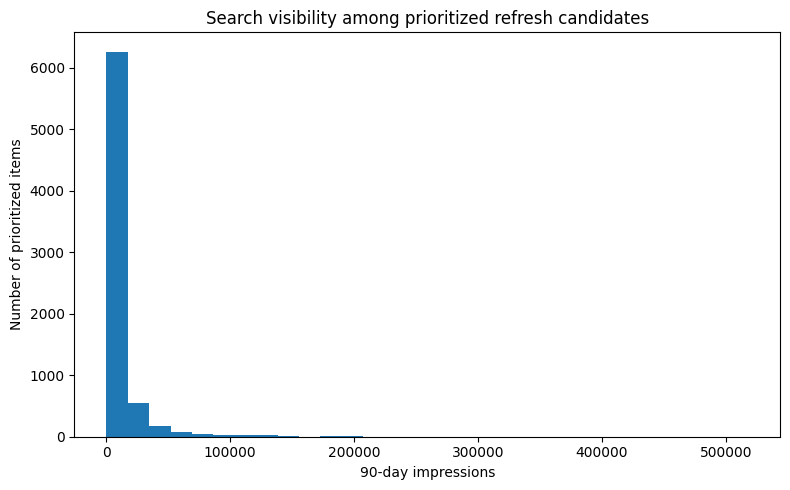

Figure saved to:
/content/flyrank-ml-internship/work/figures/action_playbook_priority_distribution.png


In [13]:
# ============================================================
# Reusable figure for the research paper
# ============================================================

import matplotlib.pyplot as plt

priority_scores = queue.loc[
    queue["score"] > 0,
    "score"
]

FIGURE_PATH = (
    FIGURES_DIR /
    "action_playbook_priority_distribution.png"
)

plt.figure(figsize=(8, 5))

if len(priority_scores) > 0:
    plt.hist(
        priority_scores,
        bins=30
    )
else:
    plt.text(
        0.5,
        0.5,
        "No priority candidates",
        ha="center",
        va="center"
    )

plt.xlabel(
    "90-day impressions"
)

plt.ylabel(
    "Number of prioritized items"
)

plt.title(
    "Search visibility among prioritized refresh candidates"
)

plt.tight_layout()

plt.savefig(
    FIGURE_PATH,
    dpi=200,
    bbox_inches="tight"
)

plt.show()

print("Figure saved to:")
print(FIGURE_PATH)

## Self-check

Before submission:

* [x] Ranked actions are generated from the previously established baseline.
* [x] Each item has a reason code.
* [x] Each prioritized item satisfies the 91–180 day condition.
* [x] Each prioritized item has at least 300 observed 90-day impressions.
* [x] Intended use is explicitly described.
* [x] Limits are explicitly described.
* [x] Human review is required before action.
* [x] A no-go list states what must not be automated.
* [x] Archetype-to-action mapping is human-reviewed rather than automatically
  inferred.
* [x] Monitoring triggers are defined.
* [x] Retraining is not claimed because the current system is rule-based.
* [x] Future/outcome information is not used in the current score.
* [x] The queue is exported for the paper.
* [x] A reusable figure is exported.
* [x] No client names, private queries, or private URLs are included.
* [x] Claims use careful language: observed, measured, directional,
  prioritization, and decision-support.


In [14]:
# ============================================================
# FINAL ML-10 SELF-CHECK
# ============================================================

# ------------------------------------------------------------
# 1. Dataset / queue integrity
# ------------------------------------------------------------

assert len(queue) == len(df), (
    "Queue length does not match dataset length."
)

priority = queue[
    queue["score"] > 0
].copy()

# ------------------------------------------------------------
# 2. Priority-rule validation
# ------------------------------------------------------------

if len(priority) > 0:

    assert priority[
        "days_since_last_update"
    ].between(91, 180).all(), (
        "Some priority items are outside the 91–180 day window."
    )

    assert (
        priority["impressions_90d"] >= 300
    ).all(), (
        "Some priority items have fewer than 300 impressions."
    )

# ------------------------------------------------------------
# 3. Reason-code validation
# ------------------------------------------------------------

assert (
    queue.loc[
        queue["score"] > 0,
        "reason_code"
    ] == "stale_visible"
).all(), (
    "Priority items must have reason_code='stale_visible'."
)

assert (
    queue.loc[
        queue["score"] == 0,
        "reason_code"
    ] == "no_priority_signal"
).all(), (
    "Non-priority items must have reason_code='no_priority_signal'."
)

# ------------------------------------------------------------
# 4. Action validation
# ------------------------------------------------------------

assert (
    queue.loc[
        queue["score"] > 0,
        "action"
    ] == "review_for_refresh"
).all(), (
    "Priority items must have action='review_for_refresh'."
)

assert (
    queue.loc[
        queue["score"] == 0,
        "action"
    ] == "no_action"
).all(), (
    "Non-priority items must have action='no_action'."
)

# ------------------------------------------------------------
# 5. Human-review validation
# ------------------------------------------------------------

assert (
    review_queue.loc[
        review_queue["action"] == "review_for_refresh",
        "review_required"
    ]
).all(), (
    "All refresh recommendations must require human review."
)

assert (
    review_queue.loc[
        review_queue["action"] == "review_for_refresh",
        "review_status"
    ] == "pending_human_review"
).all(), (
    "Priority items must be marked pending_human_review."
)

# ------------------------------------------------------------
# 6. Export validation
# ------------------------------------------------------------

assert QUEUE_PATH.exists(), (
    "Queue export was not created."
)

assert MONITORING_PATH.exists(), (
    "Monitoring export was not created."
)

assert TOP20_PATH.exists(), (
    "Top-20 export was not created."
)

assert FIGURE_PATH.exists(), (
    "Paper figure was not created."
)

# ------------------------------------------------------------
# 7. Scoring-input validation
# ------------------------------------------------------------

score_inputs = {
    "days_since_last_update",
    "impressions_90d",
}

forbidden_inputs = {
    "trend_pct",
    "trend_direction",
    "is_declining_label",
}

assert score_inputs.isdisjoint(
    forbidden_inputs
), (
    "Forbidden future/trend fields detected in scoring inputs."
)

# ------------------------------------------------------------
# 8. Reason-code / action vocabulary validation
# ------------------------------------------------------------

assert set(
    queue["reason_code"].unique()
).issubset({
    "stale_visible",
    "no_priority_signal"
})

assert set(
    queue["action"].unique()
).issubset({
    "review_for_refresh",
    "no_action"
})

# ------------------------------------------------------------
# FINAL RESULT
# ------------------------------------------------------------

print("=" * 60)
print("ML-10 SELF-CHECK: PASS")
print("=" * 60)

print(f"Total items: {len(queue):,}")
print(f"Priority candidates: {len(priority):,}")
print(
    f"Priority rate: "
    f"{len(priority) / len(queue):.2%}"
)

print("\nValidated priority rule:")
print("  - days_since_last_update: 91–180")
print("  - impressions_90d: >= 300")
print("  - score: observed 90-day impressions")

print("\nHuman review:")
print("  - Required before any refresh action")

print("\nExports:")
print(f"  Queue: {QUEUE_PATH}")
print(f"  Monitoring: {MONITORING_PATH}")
print(f"  Top 20: {TOP20_PATH}")
print(f"  Figure: {FIGURE_PATH}")

print("\nAll ML-10 checks passed.")

ML-10 SELF-CHECK: PASS
Total items: 30,000
Priority candidates: 7,212
Priority rate: 24.04%

Validated priority rule:
  - days_since_last_update: 91–180
  - impressions_90d: >= 300
  - score: observed 90-day impressions

Human review:
  - Required before any refresh action

Exports:
  Queue: /content/flyrank-ml-internship/work/outputs/content_action_playbook_queue.csv
  Monitoring: /content/flyrank-ml-internship/work/outputs/content_action_playbook_monitoring.csv
  Top 20: /content/flyrank-ml-internship/work/outputs/content_action_playbook_top20.csv
  Figure: /content/flyrank-ml-internship/work/figures/action_playbook_priority_distribution.png

All ML-10 checks passed.
